In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
points = {
  'P1': [2,10], 'P2':[2,5], 'P3':[8,4], 'P4':[5,8],
  'P5':[7,5],  'P6':[6,4], 'P7':[1,2], 'P8':[4,9]
}

In [4]:
m1 = np.array(points['P1'])   # m1 = P1 (Cluster 1)
m2 = np.array(points['P4'])   # m2 = P4 (Cluster 2)
m3 = np.array(points['P7'])   # m3 = P7 (Cluster 3)

In [5]:
assign = {}
for name, coord in points.items():
    pt = np.array(coord)
    d1 = np.linalg.norm(pt - m1)
    d2 = np.linalg.norm(pt - m2)
    d3 = np.linalg.norm(pt - m3)
    assign[name] = int(np.argmin([d1, d2, d3])) + 1
    

In [6]:
C1 = [p for p,v in assign.items() if v==1]
C2 = [p for p,v in assign.items() if v==2]
C3 = [p for p,v in assign.items() if v==3]

In [7]:
print("Cluster C1:", C1)
print("Cluster C2:", C2)
print("Cluster C3:", C3)
print()
print("1) P6 belongs to Cluster C{}".format(assign['P6']))
print("2) Population of cluster around m3 (C3):", len(C3), "->", C3)

Cluster C1: ['P1']
Cluster C2: ['P3', 'P4', 'P5', 'P6', 'P8']
Cluster C3: ['P2', 'P7']

1) P6 belongs to Cluster C2
2) Population of cluster around m3 (C3): 2 -> ['P2', 'P7']


In [8]:
# 5) Updated centroids (mean of assigned points)
new_m1 = np.mean([points[p] for p in C1], axis=0)
new_m2 = np.mean([points[p] for p in C2], axis=0)
new_m3 = np.mean([points[p] for p in C3], axis=0)

In [9]:
print("\n3) Updated centroids:")
print("   new m1 = ({:.6f}, {:.6f})".format(new_m1[0], new_m1[1]))
print("   new m2 = ({:.6f}, {:.6f})".format(new_m2[0], new_m2[1]))
print("   new m3 = ({:.6f}, {:.6f})".format(new_m3[0], new_m3[1]))


3) Updated centroids:
   new m1 = (2.000000, 10.000000)
   new m2 = (6.000000, 6.000000)
   new m3 = (1.500000, 3.500000)


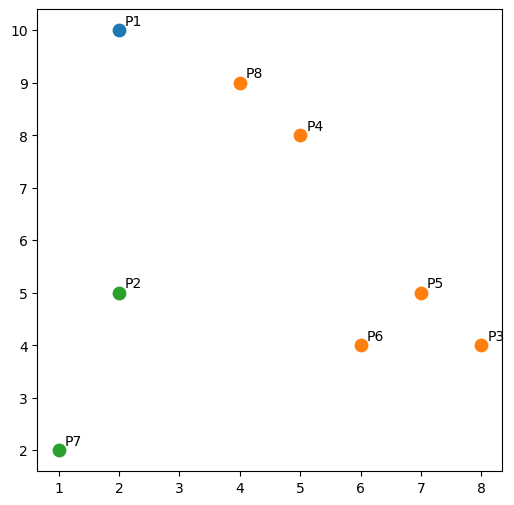

In [10]:
plt.figure(figsize=(6,6))
colors = {1:'C0', 2:'C1', 3:'C2'}
for name, (x,y) in points.items():
    plt.scatter(x, y, color=colors[assign[name]], s=80)
    plt.text(x+0.1, y+0.1, name)

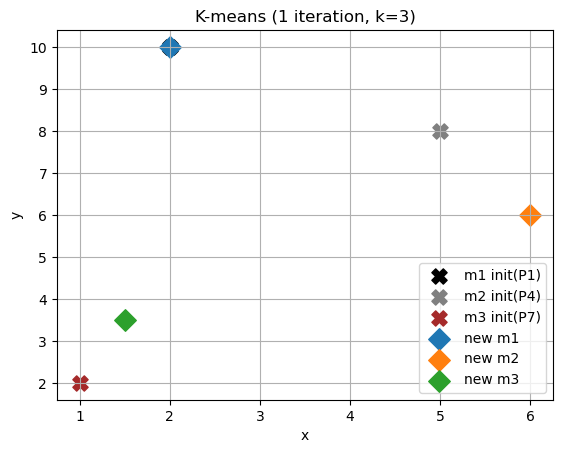

In [11]:
# plot initial and updated centroids
plt.scatter(m1[0], m1[1], marker='X', color='k', s=120, label='m1 init(P1)')
plt.scatter(m2[0], m2[1], marker='X', color='gray', s=120, label='m2 init(P4)')
plt.scatter(m3[0], m3[1], marker='X', color='brown', s=120, label='m3 init(P7)')
plt.scatter(new_m1[0], new_m1[1], marker='D', color='C0', s=120, label='new m1')
plt.scatter(new_m2[0], new_m2[1], marker='D', color='C1', s=120, label='new m2')
plt.scatter(new_m3[0], new_m3[1], marker='D', color='C2', s=120, label='new m3')
plt.legend(); plt.xlabel('x'); plt.ylabel('y'); plt.title('K-means (1 iteration, k=3)')
plt.grid(True); plt.show()